# German Train Delay Analysis
Exploratory analysis of German railway delay patterns using SQL and Python.

## Project Goal

The goal of this project is to identify:
- delay hotspots,
- problematic train lines,
- temporal delay escalation,
- and geographic railway bottlenecks.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

In [ ]:
project_root = Path.cwd().parent
db_path = project_root / "database" / "train_delay.db"

db_path

WindowsPath('c:/Users/leofi/Desktop/german-train-delay-analysis/database/train_delay.db')

## Database Connection

Connecting Python to the SQLite database containing German railway stop data.

In [ ]:
conn = sqlite3.connect(db_path)

conn

## Investigating Line 26

Previous analysis revealed that line 26 showed unusually high delay rates, especially during evening hours.

In [5]:
query = """
SELECT 
    strftime('%H', arrival_plan) AS hour,
    COUNT(*) AS total_stops,
    SUM(CASE 
        WHEN arrival_delay_m >= 6 THEN 1
        ELSE 0
    END) AS delayed_stops,
    SUM(CASE 
        WHEN arrival_delay_m >= 6 THEN 1
        ELSE 0
    END) * 100.0 / COUNT(*) AS delay_rate
FROM train_data
WHERE arrival_plan <> ''
AND line = '26'
GROUP BY hour
ORDER BY hour;
"""

In [6]:
df = pd.read_sql_query(query, conn)

df

,hour,total_stops,delayed_stops,delay_rate
0,00,379,47,12.401055
1,01,264,54,20.454545
2,02,193,11,5.699482
3,03,105,0,0.000000
4,04,297,3,1.010101
5,05,789,21,2.661597
6,06,1019,53,5.201178
7,07,1096,92,8.394161
8,08,1104,91,8.242754
9,09,1123,101,8.993767


## Delay Rate by Hour

The following visualization shows how delay rates escalate throughout the day on line 26.

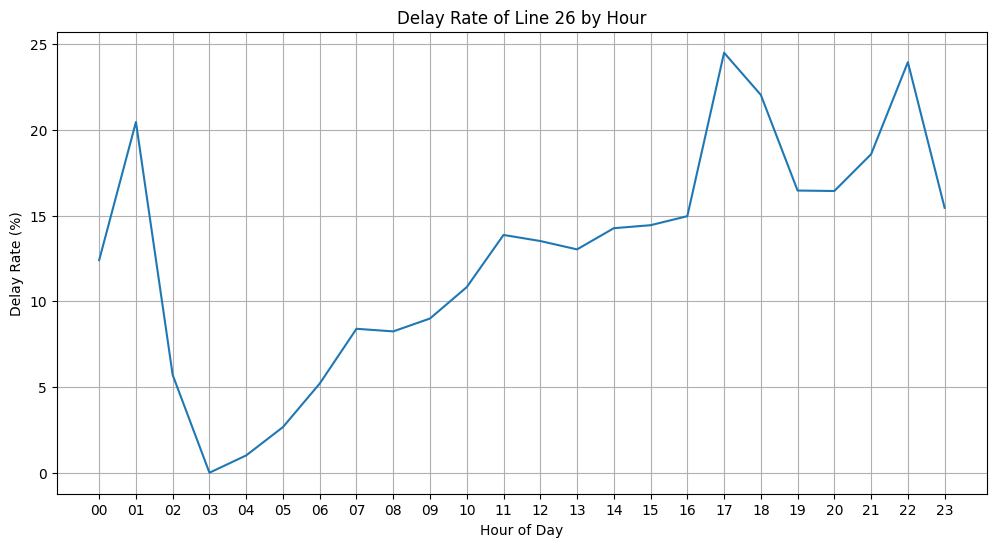

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(df['hour'], df['delay_rate'])

plt.title('Delay Rate of Line 26 by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Delay Rate (%)')

plt.grid(True)
plt.savefig(project_root / "visuals" / "line26_delay_rate_by_hour.png")

plt.show()

### Key Observation

Delay rates on line 26 increase significantly during afternoon and evening hours, peaking around 17:00–18:00.

## Delay Heatmap by State and Hour

This heatmap highlights temporal and regional delay patterns across German states.

In [8]:
heatmap_query = """
SELECT
    state,
    strftime('%H', arrival_plan) AS hour,
    SUM(CASE 
        WHEN arrival_delay_m >= 6 THEN 1
        ELSE 0
    END) * 100.0 / COUNT(*) AS delay_rate
FROM train_data
WHERE arrival_plan <> ''
GROUP BY state, hour
HAVING COUNT(*) > 1000
ORDER BY state, hour;
"""

In [9]:
heatmap_df = pd.read_sql_query(heatmap_query, conn)

heatmap_df.head(10)

,state,hour,delay_rate
0,Baden-Württemberg,00,9.505410
1,Baden-Württemberg,01,10.869565
2,Baden-Württemberg,04,1.669521
3,Baden-Württemberg,05,2.798722
4,Baden-Württemberg,06,3.461748
5,Baden-Württemberg,07,3.500913
6,Baden-Württemberg,08,5.668703
7,Baden-Württemberg,09,5.990388
8,Baden-Württemberg,10,6.974138
9,Baden-Württemberg,11,6.164560


In [10]:
pivot_df = heatmap_df.pivot(
    index='state',
    columns='hour',
    values='delay_rate'
)

pivot_df

hour,00,01,02,03,04,05,06,07,08,09,...,14,15,16,17,18,19,20,21,22,23
state,,,,,,,,,,,,,,,,,,,,,
Baden-Württemberg,9.505410,10.869565,NaN,NaN,1.669521,2.798722,3.461748,3.500913,5.668703,5.990388,...,8.823529,8.421139,9.345048,12.089398,13.876295,13.358055,10.392678,8.845478,7.642613,8.451285
Bayern,9.043454,8.079229,8.860759,NaN,1.308044,1.603459,2.597156,3.974185,7.573397,8.129176,...,9.472828,7.249549,9.660055,11.673197,13.943496,11.618037,7.941218,7.182110,7.689204,8.742549
Berlin,1.790885,1.874887,2.080679,0.746640,0.428516,0.430074,0.280093,0.514548,0.969938,0.889539,...,1.928862,2.990750,1.796782,1.956337,2.327581,2.121700,1.714813,1.926769,2.225131,1.857972
Brandenburg,7.374890,NaN,NaN,NaN,1.945854,0.698324,0.979992,2.469620,3.129890,4.288026,...,6.919731,8.349074,8.215514,7.313376,7.824427,9.123506,5.274725,6.805019,7.890319,4.815303
Hamburg,1.030928,0.275634,NaN,NaN,0.046882,0.528518,0.295582,0.443114,0.810654,1.649427,...,1.076471,3.469528,2.980642,2.898710,3.301832,3.451098,1.129944,0.459395,1.780694,0.773196
Hessen,5.538349,6.580830,3.021719,4.233227,2.321603,2.774695,3.452841,4.702614,4.495942,9.331721,...,5.586470,6.247393,7.954084,9.068972,9.743225,8.742932,9.719170,8.538075,8.176191,7.265660
Mecklenburg-Vorpommern,NaN,NaN,NaN,NaN,NaN,NaN,0.756859,2.814424,NaN,NaN,...,2.767102,3.933434,4.150943,4.166667,NaN,NaN,NaN,NaN,NaN,NaN
Niedersachsen,12.108683,NaN,NaN,NaN,NaN,2.988420,4.030227,4.464286,5.637323,5.711850,...,7.664933,6.629093,6.119792,8.097586,7.446809,6.980609,7.239688,7.102859,4.781997,6.380368
Nordrhein-Westfalen,8.596066,8.776844,5.980684,5.192802,1.800970,3.032472,5.105986,4.851634,6.771486,6.232471,...,14.048183,12.602871,10.958741,11.732274,10.284398,10.546574,10.202361,8.712091,8.326993,7.184048


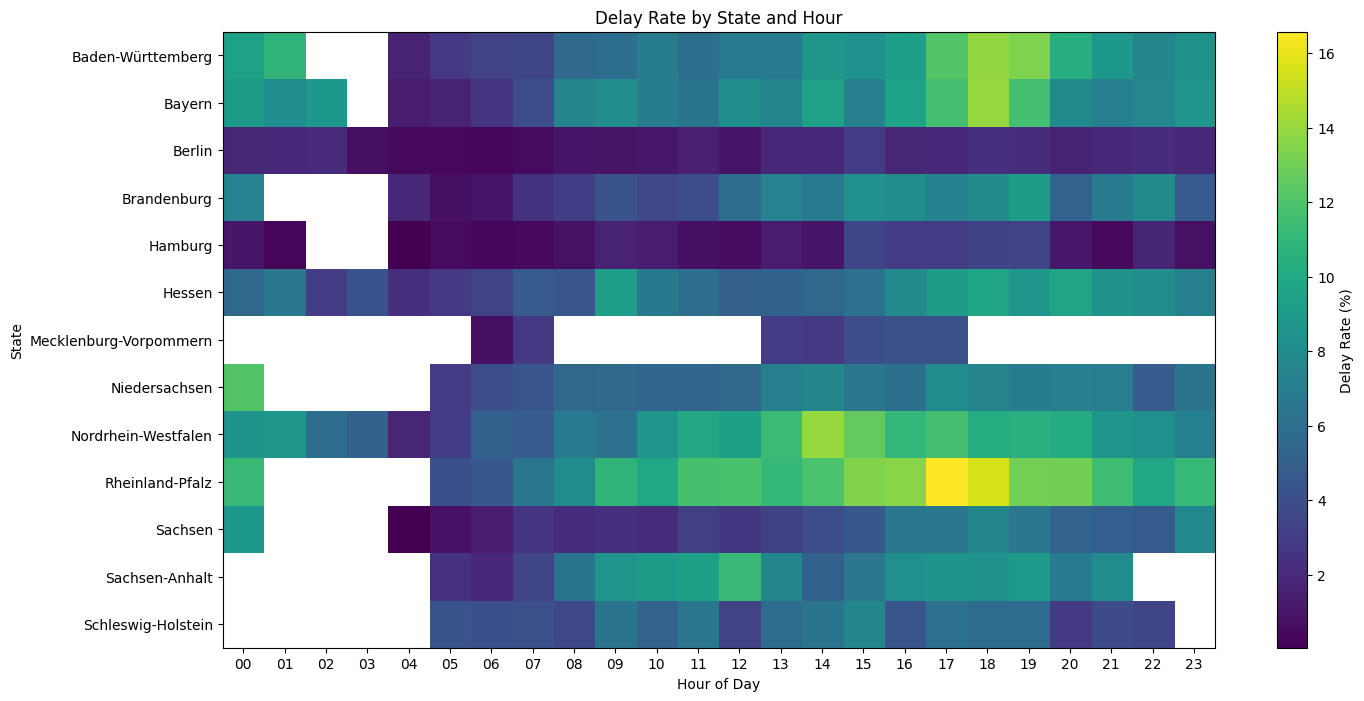

In [11]:
plt.figure(figsize=(16, 8))

plt.imshow(pivot_df, aspect='auto')
plt.colorbar(label='Delay Rate (%)')

plt.xticks(
    ticks=range(len(pivot_df.columns)),
    labels=pivot_df.columns
)

plt.yticks(
    ticks=range(len(pivot_df.index)),
    labels=pivot_df.index
)

plt.title('Delay Rate by State and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('State')

plt.savefig(project_root / "visuals" / "delay_rate_by_state_and_hour.png", bbox_inches="tight")
plt.show()

### Key Observation

Rheinland-Pfalz showed consistently elevated delay rates, especially during evening rush hours.

## Geographic Delay Hotspots

Interactive map visualization of major delay hotspots along the Rhine corridor.

In [ ]:
map_query = """
SELECT 
    station,
    lat,
    long,
    COUNT(*) AS total_stops,
    SUM(CASE 
        WHEN arrival_delay_m >= 6 THEN 1
        ELSE 0
    END) AS delayed_stops,
    SUM(CASE 
        WHEN arrival_delay_m >= 6 THEN 1
        ELSE 0
    END) * 100.0 / COUNT(*) AS delay_rate
FROM train_data
WHERE arrival_plan <> ''
AND line = '26'
AND state IN ('Rheinland-Pfalz', 'Nordrhein-Westfalen', 'Hessen')
GROUP BY station, lat, long
HAVING total_stops > 100
ORDER BY delay_rate DESC;
"""

In [16]:
map_df = pd.read_sql_query(map_query, conn)

map_df.head()

,station,lat,long,total_stops,delayed_stops,delay_rate
0,Mülheim-Kärlich,50.402613,7.509072,304,112,36.842105
1,Weißenthurm,50.421177,7.450988,304,109,35.855263
2,Koblenz Stadtmitte,50.357714,7.589985,304,105,34.539474
3,St. Goar,50.150155,7.714587,305,104,34.098361
4,Koblenz Hbf,50.350929,7.588345,288,98,34.027778


In [17]:
fig = px.scatter_mapbox(
    map_df,
    lat="lat",
    lon="long",
    size="total_stops",
    color="delay_rate",
    hover_name="station",
    hover_data=["total_stops", "delayed_stops", "delay_rate"],
    zoom=5,
    height=700,
    title="Delay Hotspots on Line 26"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

C:\Users\leofi\AppData\Local\Temp\ipykernel_20324\4143381823.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Key Observation

Geographic clustering revealed major delay hotspots along the Rhine corridor between Cologne and Mainz.

In [18]:
fig.write_html(
    project_root / "visuals" / "line26_delay_hotspots_map.html"
)